# IMPORTE DE LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

LECTURA DE DATOS

In [ ]:
df = pd.read_csv('DatosSeguros.csv')

INFORMACION DEL DATAFRAME

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad          1349 non-null   int64  
 1   sexo          1349 non-null   object 
 2   imc           1347 non-null   float64
 3   hijos         1349 non-null   int64  
 4   fumador       1347 non-null   object 
 5   region        1349 non-null   object 
 6   valor_seguro  1349 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.9+ KB


MANIPULACION DE DATOS - PREPARAR EL DATAFRAME

In [ ]:
df.isnull().sum()

,0
edad,0
sexo,0
imc,2
hijos,0
fumador,2
region,0
valor_seguro,0


ELIMINACION DE VALORES NULOS

In [ ]:
df=df.dropna()
df.isnull().sum()

,0
edad,0
sexo,0
imc,0
hijos,0
fumador,0
region,0
valor_seguro,0


DATASET ACTUALIZADO

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345 entries, 0 to 1348
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad          1345 non-null   int64  
 1   sexo          1345 non-null   object 
 2   imc           1345 non-null   float64
 3   hijos         1345 non-null   int64  
 4   fumador       1345 non-null   object 
 5   region        1345 non-null   object 
 6   valor_seguro  1345 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 84.1+ KB


DUPLICADOS EN EL DATASET

In [ ]:
df.duplicated().sum()

np.int64(12)

ELIMINACION DE DUPLICADOS

In [ ]:
df=df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1333 entries, 0 to 1347
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad          1333 non-null   int64  
 1   sexo          1333 non-null   object 
 2   imc           1333 non-null   float64
 3   hijos         1333 non-null   int64  
 4   fumador       1333 non-null   object 
 5   region        1333 non-null   object 
 6   valor_seguro  1333 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.3+ KB


CREACION DE RANGOS DE EDAD

*   17 a 28 - RANGO A
*   29 a 38 - RANGO B
*   39 a 48 - RANGO C
*   49 a 58 - RANGO D
*   59 a 68 - RANGO E


In [ ]:
rangos = [17, 28, 38, 48, 58, 68]
nombre_rango = ["A (17-28)", "B (29-38)", "C (39-48)", "D (49-58)", "E (59-68)"]
df['rango_edad'] = pd.cut(df['edad'], rangos, labels = nombre_rango)
df.head(10)



,edad,sexo,imc,hijos,fumador,region,valor_seguro,rango_edad
0,19,F,27.900,0,yes,Caribe,16884.92400,A (17-28)
3,18,M,33.770,1,no,Cundinamarca,1725.55230,A (17-28)
4,28,M,33.000,3,no,Cundinamarca,4449.46200,A (17-28)
5,33,M,22.705,0,no,Antioquia,21984.47061,B (29-38)
6,32,M,28.880,0,no,Antioquia,3866.85520,B (29-38)
7,31,F,25.740,0,no,Cundinamarca,3756.62160,B (29-38)
8,46,F,33.440,1,no,Cundinamarca,8240.58960,C (39-48)
9,37,F,27.740,3,no,Antioquia,7281.50560,B (29-38)
10,37,M,29.830,2,no,Boyaca,6406.41070,B (29-38)
11,60,F,25.840,0,no,Antioquia,28923.13692,E (59-68)


# VALORES ESTADISITCOS DEL DF

In [ ]:
df.describe().style.format({
    'edad': '{:.0f}',
    'hijos': '{:.0f}',
    'imc': '{:.2f}',
    'valor_seguro': '{:.0f}'
})

,edad,imc,hijos,valor_seguro
count,1333,1333.00,1333,1333
mean,39,30.65,1,13262
std,14,6.10,1,12094
min,18,15.96,0,1122
25%,27,26.22,0,4738
50%,39,30.36,1,9378
75%,51,34.67,2,16658
max,64,53.13,5,63770


MEDIDAS DE TENDENCIA CENTRAL Y DE DISPERSION

# PREGUNTAS DE ANALISIS

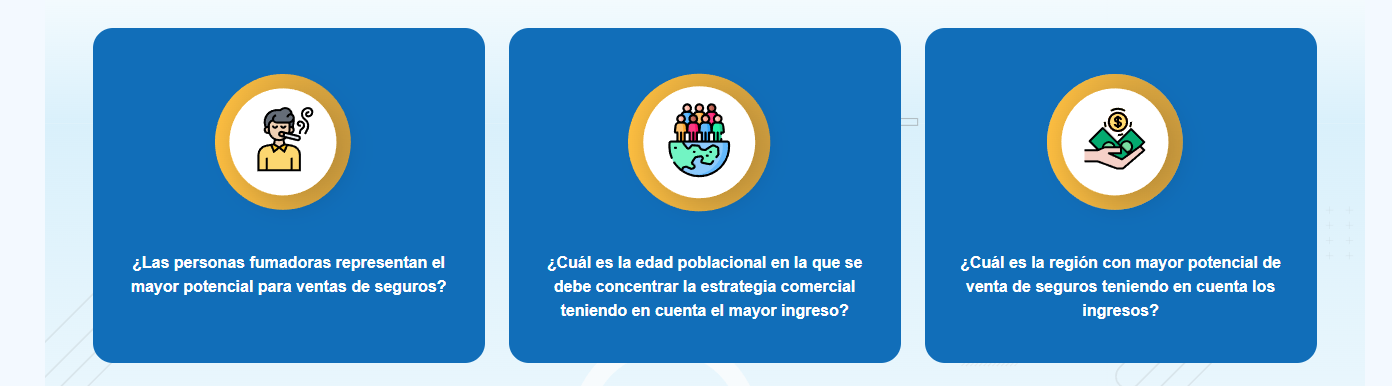

# GRAFICO PARA PREGUNTA 1: ¿LAS PERSONAS FUMADORAS REPRESENTAN EL MAYOR POTENCIAL PARA VENTAS DE SEGUROS?

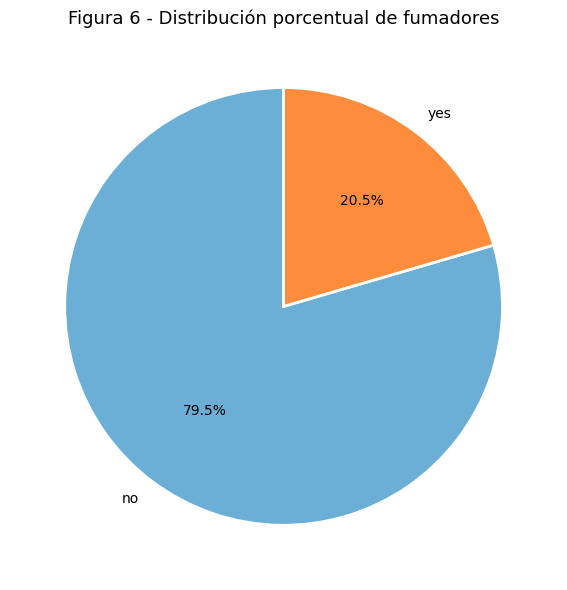

In [ ]:
conteo_fumadores = df['fumador'].value_counts()

colores = ['#6baed6', '#fd8d3c']  # azul = no, naranja = yes
etiquetas = ['no', 'yes']

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    conteo_fumadores,
    labels=etiquetas,
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax.set_title('Figura 6 - Distribución porcentual de fumadores', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13987/2076529067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


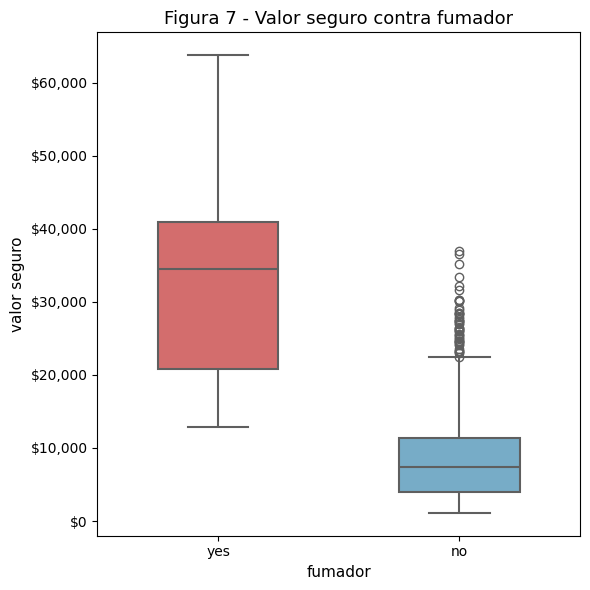

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

sns.boxplot(
    data=df,
    x='fumador',
    y='valor_seguro',
    order=['yes', 'no'],
    palette={'yes': '#e45c5c', 'no': '#6ab0d4'},
    width=0.5,
    linewidth=1.5,
    ax=ax)

ax.set_title('Figura 7 - Valor seguro contra fumador', fontsize=13)
ax.set_xlabel('fumador', fontsize=11)
ax.set_ylabel('valor seguro', fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

([<matplotlib.patches.Wedge at 0x78cd9a66cb60>,
 [Text(-1.0998141147539884, -0.020221597066035536, 'no'),
  Text(1.099814117807352, 0.020221430998724185, 'yes')],
 [Text(-0.59989860804763, -0.011029962036019381, '50.6%'),
  Text(0.599898609713101, 0.011029871453849554, '49.4%')])

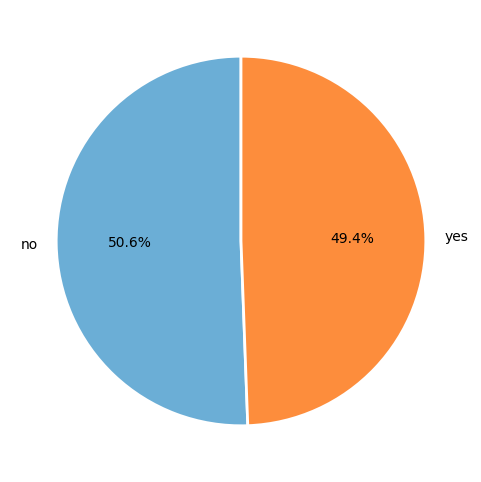

In [ ]:
total_por_grupo = df.groupby('fumador')['valor_seguro'].sum()
colores = ['#6baed6', '#fd8d3c']
etiquetas = ['no', 'yes']
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    total_por_grupo,
    labels=etiquetas,
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# GRAFICO PARA PREGUNTA 2: ¿CUAL ES LA EDAD POBLACIONAL EN LA QUE SE DEBE CONCENTRAR LA ESTRATEGIA COMERCIAL TENIENDO EN CUENTA EL MAYOR INGRESO?

/tmp/ipykernel_13987/3004433794.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_rango_edad = df['rango_edad'].groupby(df['rango_edad']).count()


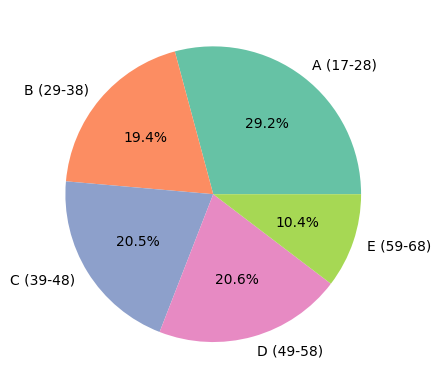

In [ ]:
total_rango_edad = df['rango_edad'].groupby(df['rango_edad']).count()
labels = ["A (17-28)", "B (29-38)", "C (39-48)", "D (49-58)", "E (59-68)"]
colors = sns.color_palette('Set2')[0:5]

plt.pie(total_rango_edad, labels = labels, colors = colors, autopct='%.1f%%')
plt.show()

<Axes: >

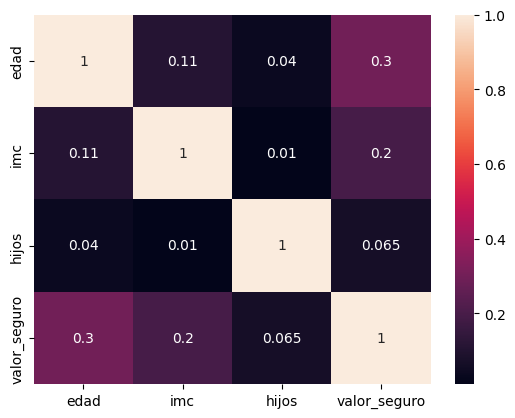

In [ ]:
columnas_numericas = df[['edad', 'imc', 'hijos', 'valor_seguro']]
correlacion = columnas_numericas.corr()
correlacion

sns.heatmap(
    correlacion,
    xticklabels=correlacion.columns,
    yticklabels=correlacion.columns,
    annot=True)

<Axes: >

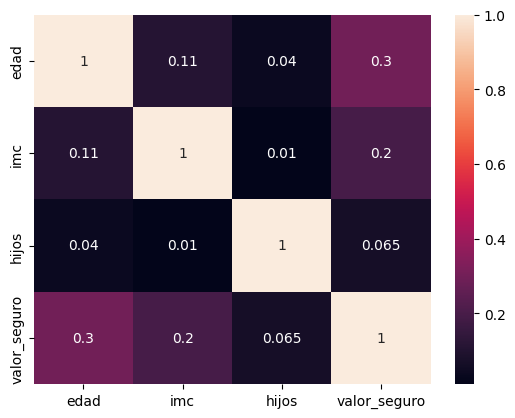

In [ ]:
correlacion = df.select_dtypes(include='number').corr()
correlacion

sns.heatmap(
    correlacion,
    xticklabels=correlacion.columns,
    yticklabels=correlacion.columns,
    annot=True
)

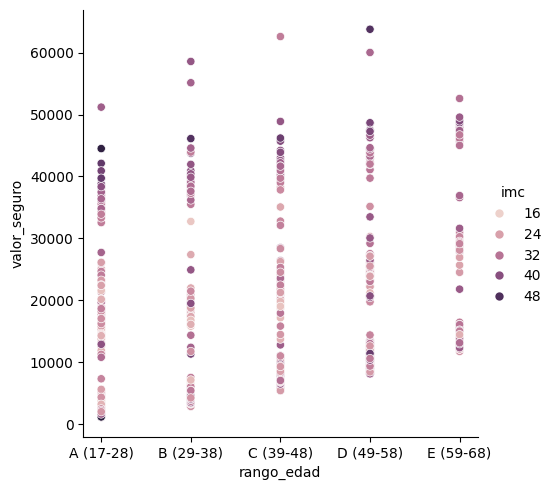

In [ ]:
sns.relplot(x='rango_edad' ,y='valor_seguro',hue='imc',data=df)

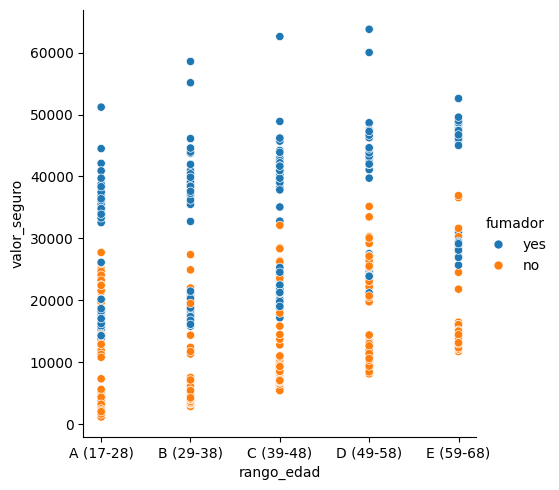

In [ ]:
sns.relplot(x='rango_edad',
y='valor_seguro',hue='fumador',data=df)

# GRAFICO PARA PREGUNTA 3: ¿CUAL ES LA REGION CON MAS POTENCIAL DE VENTA DE SEGUROS TENIENDO EN CUENTA LOS INGRESOS?

<Axes: xlabel='region', ylabel='valor_seguro'>

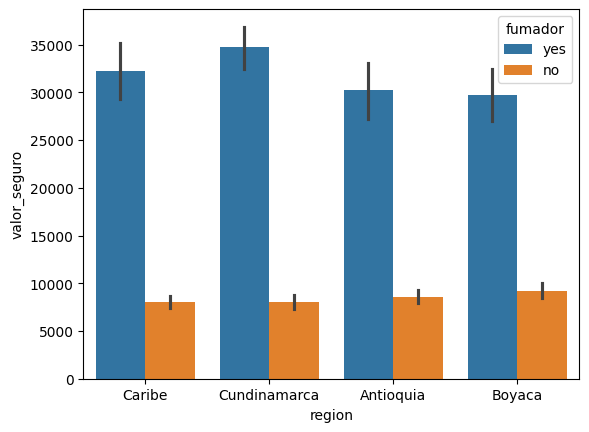

In [ ]:
sns.barplot(data=df,x='region',y='valor_seguro',hue='fumador')